# Pending experiments for **Where Credit Enters a Computation**

Run this notebook from the root of `aayushmanda/Trace`.

It is written against the current repository API (`src.registry`, `src.boolean_circuit_tasks`, `compare_supervision.py`, `sweep_ratio.py`) and is designed to resolve the experiments marked **[pending]** in the identifiability draft.

The notebook contains:

1. **Informative / uninformative gradient ratio**: measure `||Pi_C G|| / ||Pi_R G||` at four `phi` values and `D in {3,4,6}`.
2. **Neighborhood coupling radius**: pair examples from two reversible executors by `(g_1:D, s_D)` and measure the gradient-law distance against `phi^(D-1)` and the theorem bound.
3. **Reversibility dial**: replace a controlled fraction of the 52 Boolean gate meanings by minimally non-injective maps and train the full two-block Transformer under OUTCOME and PROCESS.
4. **Supervision stride**: train the full Transformer with every `k`-th state supervised, plus a matrix-model stride experiment that actually tests the predicted `epsilon^{-(k-2)}` exponent.
5. **Degree-graded finite differences**: exact matrix positive control (`D` versus `1`) plus a reusable Transformer finite-difference harness. The current paper does not specify a unique Transformer executor direction `d`; this notebook does not silently invent one.
6. **Trace-cleaning protocol audit**: inspect the released implementation and print exactly what its `f` means.
7. **Reviewer-critical optimizer robustness**: rerun the matrix escape experiment with direct-coordinate AdamW next to projected GD.

Start with `PROFILE = "pilot"`. Switch to `"paper"` only after every pilot cell passes its assertions.


In [21]:
from __future__ import annotations

import copy, csv, hashlib, inspect, json, math, os, random, re, subprocess, time
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

ROOT = Path.cwd()
assert (ROOT / "src" / "registry.py").exists(), "Run this notebook from the Trace repository root."

from src.registry import TASKS
from src.dataclass import Task, Instance
from src.boolean_circuit_tasks import _apply_gate, _bits, _sample_gate
from src.model import GPTModel
from compare_supervision import SupervisionDataset, train_one as repo_train_one
from sweep_ratio import evaluate as repo_rollout_evaluate
from data_cleaning_validation import build_filtered_subset

PROFILE = "paper"   # <- change to "paper" for final runs
assert PROFILE in {"pilot", "paper"}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda": torch.set_float32_matmul_precision("high")

OUT = ROOT / "results" / "pending_identifiability" / PROFILE
OUT.mkdir(parents=True, exist_ok=True)

try:
    GIT_SHA = subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip()
except Exception:
    GIT_SHA = "unknown"

print("profile:", PROFILE)
print("device :", DEVICE)
print("git sha:", GIT_SHA)
print("output :", OUT)


profile: paper
device : cuda
git sha: 023aeea7a5e3dbea0dc7a2f072fa66221d41a7fa
output : /home/aayus/Trace/results/pending_identifiability/paper


In [ ]:
@dataclass(frozen=True)
class Profile:
    seeds: tuple[int, ...]
    train_size: int
    val_size: int
    steps: int
    checkpoints: tuple[int, ...]
    eval_batch_size: int
    workers: int
    matrix_batch: int
    matrix_sequences: int

PILOT = Profile(
    seeds=(2001,), train_size=12_000, val_size=500, steps=2_000,
    checkpoints=(250, 500, 1000, 2000), eval_batch_size=128, workers=2,
    matrix_batch=128, matrix_sequences=96,
)
PAPER = Profile(
    seeds=(2001, 2002, 2003, 2004, 2005), train_size=100_000, val_size=2_000, steps=8_000,
    checkpoints=(500, 1000, 2000, 4000, 8000), eval_batch_size=256, workers=4,
    matrix_batch=512, matrix_sequences=480,
)
CFG = PAPER if PROFILE == "pilot" else PAPER

TRAIN_ARGS = SimpleNamespace(
    batch_seed=12345, batch_size=128, eval_batch_size=CFG.eval_batch_size,
    workers=CFG.workers, steps=CFG.steps, lr=3e-4, weight_decay=0.0,
    grad_clip=1.0, embedding=128, heads=4, layers=2, dropout=0.0,
)

metadata = {
    "profile": PROFILE, "git_sha": GIT_SHA, "device": str(DEVICE),
    "seeds": list(CFG.seeds), "train_size": CFG.train_size, "val_size": CFG.val_size,
    "steps": CFG.steps,
}
(OUT / "run_metadata.json").write_text(json.dumps(metadata, indent=2))
metadata


{'profile': 'paper',
 'git_sha': '023aeea7a5e3dbea0dc7a2f072fa66221d41a7fa',
 'device': 'cuda',
 'seeds': [2001, 2002, 2003, 2004, 2005],
 'train_size': 100000,
 'val_size': 2000,
 'steps': 8000}

## Shared reversible-executor utilities

The repository Boolean family has 16 states and 52 operation strings. The helper below uses the repository's actual `_apply_gate` semantics rather than reimplementing them.


In [23]:
K, N_BITS = 16, 4
U = torch.full((K, K), 1.0 / K, dtype=torch.float64)


def enumerate_repo_gate_strings():
    gates=[]
    gates += [f"x{i}" for i in range(N_BITS)]
    gates += [f"c{i}{j}" for i in range(N_BITS) for j in range(N_BITS) if i != j]
    gates += [f"s{i}{j}" for i in range(N_BITS) for j in range(N_BITS) if i != j]
    gates += [f"t{i}{j}{k}" for i in range(N_BITS) for j in range(N_BITS) for k in range(N_BITS) if len({i,j,k}) == 3]
    assert len(gates) == 52
    return gates

GATES = enumerate_repo_gate_strings()
M = len(GATES)
GATE_TO_ID = {g:i for i,g in enumerate(GATES)}


def bits_to_int(bits): return int("".join(str(int(b)) for b in bits), 2)
def state_text(s): return f"{int(s):04b}"


def repo_executor_table():
    table=np.empty((M,K), dtype=np.int64)
    for gi,g in enumerate(GATES):
        out=[bits_to_int(_apply_gate(_bits(s), g)) for s in range(K)]
        assert sorted(out) == list(range(K)), g
        table[gi]=out
    return table

TRUE_REPO = repo_executor_table()


def random_permutation_executor(seed=991):
    rng=np.random.default_rng(seed)
    return np.stack([rng.permutation(K) for _ in range(M)]).astype(np.int64)


def inverse_perm_table(table):
    inv=np.empty_like(table)
    for g in range(table.shape[0]):
        assert sorted(table[g].tolist()) == list(range(K))
        inv[g, table[g]] = np.arange(K)
    return inv


def apply_sequence(table, s0, gate_ids):
    s=np.asarray(s0, dtype=np.int64).copy()
    for t in range(gate_ids.shape[-1]):
        s=table[gate_ids[...,t], s]
    return s


def invert_sequence(inv_table, y, gate_ids):
    s=np.asarray(y, dtype=np.int64).copy()
    for t in range(gate_ids.shape[-1]-1, -1, -1):
        s=inv_table[gate_ids[...,t], s]
    return s


def sample_gate_ids(n, depth, seed):
    state=random.getstate(); random.seed(seed)
    rows=[[GATE_TO_ID[_sample_gate()] for _ in range(depth)] for _ in range(n)]
    random.setstate(state)
    return np.asarray(rows, dtype=np.int64)

print("K=", K, "M=", M, "first gates=", GATES[:8])


K= 16 M= 52 first gates= ['x0', 'x1', 'x2', 'x3', 'c01', 'c02', 'c03', 'c10']


## Matrix-gradient helpers

For a fixed learned executor `P`, the projected per-example terminal gradient decomposes exactly as

\[
G_t^C = \frac{(\Pi q_{t-1})(\Pi\beta_t)^\top}{p_y},\qquad
G_t^R = \frac{\mathbf 1(\Pi\beta_t)^\top}{Kp_y}.
\]

The functions below evaluate these expressions directly. This avoids autograd noise and makes the coupling experiment a genuine numerical check of the theorem.


In [24]:
def make_learned_P(phi, seed=1234, device=DEVICE):
    rng=np.random.default_rng(seed)
    R=np.stack([np.eye(K)[rng.permutation(K)] for _ in range(M)])
    # np.eye(K)[perm] is a permutation matrix; (1-phi)U + phi R has gamma=0 and ||F||op=phi.
    P=(1.0-phi)*(np.ones((M,K,K))/K) + phi*R
    return torch.tensor(P, dtype=torch.float64, device=device)


def split_RC_tensor(X):
    # X is already row-tangent: row sums are zero. c^T=(1/K)1^T X.
    c=X.mean(dim=-2, keepdim=True)
    Rpart=c.expand_as(X)
    Cpart=X-Rpart
    return Rpart, Cpart


def phi_gamma(P):
    E=P-torch.full_like(P, 1.0/K)
    c=E.mean(dim=-2)
    Fpart=E-c[:,None,:]
    phi=float(torch.linalg.matrix_norm(Fpart, ord=2).max())
    gamma=float(torch.linalg.vector_norm(c, dim=-1).max())
    return phi, gamma


def gradient_components_batch(P, s0, gate_idx, y):
    """Exact projected negative terminal gradient, accumulated into gate blocks.

    Returns R,C with shape [B,M,K,K]. Intended for diagnostic batches, not training.
    """
    s0=torch.as_tensor(s0, device=P.device, dtype=torch.long)
    gate_idx=torch.as_tensor(gate_idx, device=P.device, dtype=torch.long)
    y=torch.as_tensor(y, device=P.device, dtype=torch.long)
    B,D=gate_idx.shape
    eye=torch.eye(K, dtype=P.dtype, device=P.device)
    q=eye[s0]
    q_before=[]
    for t in range(D):
        q_before.append(q)
        Pt=P[gate_idx[:,t]]
        q=torch.bmm(q[:,None,:], Pt).squeeze(1)
    py=q.gather(1,y[:,None]).squeeze(1).clamp_min(1e-15)

    beta=eye[y]
    betas=[None]*D
    for t in range(D-1,-1,-1):
        betas[t]=beta
        Pt=P[gate_idx[:,t]]
        beta=torch.bmm(Pt, beta[:,:,None]).squeeze(2)

    R=torch.zeros(B,M,K,K, dtype=P.dtype, device=P.device)
    C=torch.zeros_like(R)
    ones=torch.ones(B,K, dtype=P.dtype, device=P.device)/K
    ar=torch.arange(B, device=P.device)
    for t in range(D):
        qc=q_before[t]-1.0/K
        bc=betas[t]-betas[t].mean(dim=1, keepdim=True)
        scale=1.0/py
        Ct=qc[:,:,None]*bc[:,None,:]*scale[:,None,None]
        Rt=ones[:,:,None]*bc[:,None,:]*scale[:,None,None]
        g=gate_idx[:,t]
        C[ar,g] += Ct
        R[ar,g] += Rt
    return R,C


def flat_norm(X): return torch.linalg.vector_norm(X.reshape(X.shape[0],-1), dim=1)


# Pending 1 — amplification ratio `||Pi_C G|| / ||Pi_R G||`

This uses four controlled `phi` values and depths 3, 4, 6. We report both per-example RMS ratios and a fixed-batch aggregate ratio. The cleanest theorem signature is that the informative `C` component falls with depth order while the `R` component survives.


,D,phi,rms_R,rms_C,median_C_over_R,batch_R,batch_C,batch_C_over_R,phi_Dm1
0,3,0.40,4.396922,4.331925,0.985728,0.195684,1.924984e-01,0.983720,1.600000e-01
1,3,0.20,3.957741,1.040357,0.262915,0.174074,4.603960e-02,0.264483,4.000000e-02
2,3,0.10,3.892447,0.259770,0.066746,0.170445,1.148686e-02,0.067393,1.000000e-02
3,3,0.05,3.877726,0.064941,0.016750,0.169565,2.871361e-03,0.016934,2.500000e-03
4,4,0.40,4.256934,1.934907,0.454504,0.192077,8.495317e-02,0.442287,6.400000e-02
5,4,0.20,3.952273,0.239934,0.060716,0.176115,1.053294e-02,0.059807,8.000000e-03
6,4,0.10,3.892546,0.029996,0.007707,0.172237,1.316878e-03,0.007646,1.000000e-03
7,4,0.05,3.877907,0.003749,0.000967,0.171050,1.646125e-04,0.000962,1.250000e-04
8,6,0.40,4.222405,0.376808,0.089036,0.192809,1.649061e-02,0.085528,1.024000e-02
9,6,0.20,3.952079,0.011779,0.002974,0.178002,5.155588e-04,0.002896,3.200000e-04


,D,ratio_loglog_slope,reference_D_minus_1
0,3,1.961484,2
1,4,2.960733,3
2,6,4.960595,5


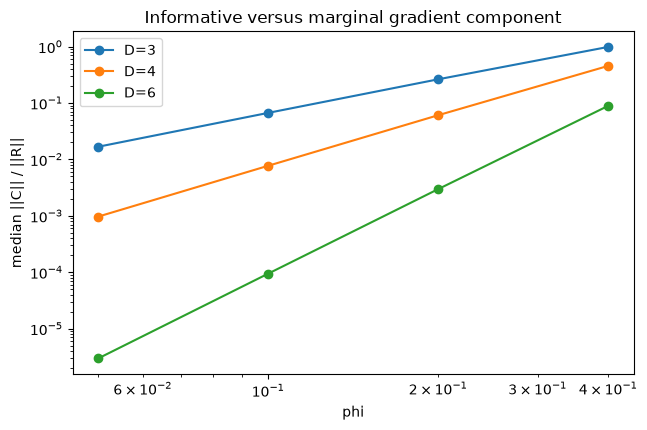

In [25]:
def run_amplification_ratio():
    rows=[]
    phis=[0.40,0.20,0.10,0.05]
    depths=[3,4,6]
    B=CFG.matrix_batch
    for D in depths:
        gate_idx=sample_gate_ids(B,D,seed=7100+D)
        rng=np.random.default_rng(7200+D)
        s0=rng.integers(0,K,size=B)
        y=apply_sequence(TRUE_REPO,s0,gate_idx)
        for phi in phis:
            P=make_learned_P(phi, seed=7300+D)
            R,C=gradient_components_batch(P,s0,gate_idx,y)
            rn,cn=flat_norm(R),flat_norm(C)
            Rbar,Cbar=R.mean(0),C.mean(0)
            row={
                "D":D,"phi":phi,
                "rms_R":float(torch.sqrt((rn**2).mean())),
                "rms_C":float(torch.sqrt((cn**2).mean())),
                "median_C_over_R":float(torch.median(cn/rn.clamp_min(1e-30))),
                "batch_R":float(torch.linalg.vector_norm(Rbar)),
                "batch_C":float(torch.linalg.vector_norm(Cbar)),
                "batch_C_over_R":float(torch.linalg.vector_norm(Cbar)/torch.linalg.vector_norm(Rbar).clamp_min(1e-30)),
                "phi_Dm1":phi**(D-1),
            }
            rows.append(row)
            del R,C
            if DEVICE.type=="cuda": torch.cuda.empty_cache()
    df=pd.DataFrame(rows)
    df.to_csv(OUT/"p1_amplification_ratio.csv",index=False)

    fits=[]
    for D,g in df.groupby("D"):
        x=np.log(g.phi.to_numpy()); y=np.log(g.median_C_over_R.to_numpy())
        slope,intercept=np.polyfit(x,y,1)
        fits.append({"D":D,"ratio_loglog_slope":slope,"reference_D_minus_1":D-1})
    fitdf=pd.DataFrame(fits)
    fitdf.to_csv(OUT/"p1_amplification_ratio_fits.csv",index=False)
    display(df)
    display(fitdf)

    fig,ax=plt.subplots(figsize=(6.6,4.4))
    for D,g in df.groupby("D"):
        ax.loglog(g.phi,g.median_C_over_R,marker="o",label=f"D={D}")
    ax.set_xlabel("phi")
    ax.set_ylabel("median ||C|| / ||R||")
    ax.set_title("Informative versus marginal gradient component")
    ax.legend(); fig.tight_layout(); plt.show()
    return df,fitdf

amp_df,amp_fits=run_amplification_ratio()


# Pending 2 — coupling radius between two executors

For each gate sequence and terminal state `y`, reversibility gives a unique start state under each executor. We use this to build the theorem's coupling by matching `(g_1:D, y)` exactly. The learned parameter `P` is shared.

The notebook records:

- `max ||G-G'||_F`,
- its `R` and `C` components separately,
- the theorem radius `4 K D sqrt(M) phi^(D-1)` in the `gamma=0` construction,
- the fitted log-log slope versus `phi`.


,D,phi,gamma,max_full_diff,median_full_diff,max_C_diff,max_R_diff,theorem_radius,max_over_bound,phi_Dm1
0,3,0.40,1.734723e-17,8.374324,6.486723,8.374324,2.353872e+00,221.525070,0.037803,1.600000e-01
1,3,0.20,9.813078e-18,1.975395,1.530134,1.975395,4.553826e-01,55.381268,0.035669,4.000000e-02
2,3,0.10,4.906539e-18,0.490388,0.379853,0.490388,6.142091e-02,13.845317,0.035419,1.000000e-02
3,3,0.05,1.040834e-17,0.122490,0.094880,0.122490,7.742120e-03,3.461329,0.035388,2.500000e-03
4,4,0.40,1.734723e-17,2.983938,2.878017,2.925590,1.310388e+00,118.146704,0.025256,6.400000e-02
5,4,0.20,9.813078e-18,0.399188,0.351104,0.386683,9.913133e-02,14.768338,0.027030,8.000000e-03
6,4,0.10,4.906539e-18,0.049341,0.043822,0.048948,6.219901e-03,1.846042,0.026728,1.000000e-03
7,4,0.05,1.040834e-17,0.006136,0.005477,0.006123,3.877519e-04,0.230755,0.026589,1.250000e-04
8,6,0.40,1.734723e-17,0.646505,0.551796,0.596008,2.950983e-01,28.355209,0.022800,1.024000e-02
9,6,0.20,9.813078e-18,0.019008,0.017174,0.018550,4.196513e-03,0.886100,0.021452,3.200000e-04


,D,measured_slope,predicted_D_minus_1
0,3,2.029586,2
1,4,2.979355,3
2,6,5.039039,5


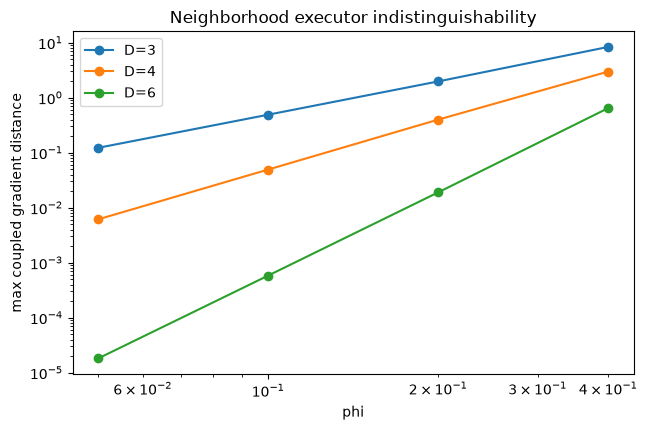

In [26]:
def run_coupling_radius():
    T1=TRUE_REPO
    T2=random_permutation_executor(881)
    inv1,invr2=inverse_perm_table(T1),inverse_perm_table(T2)
    phis=[0.40,0.20,0.10,0.05]
    depths=[3,4,6]
    B=CFG.matrix_batch
    rows=[]
    for D in depths:
        gates=sample_gate_ids(B,D,seed=8100+D)
        rng=np.random.default_rng(8200+D)
        y=rng.integers(0,K,size=B)
        s01=invert_sequence(inv1,y,gates)
        s02=invert_sequence(invr2,y,gates)
        assert np.all(apply_sequence(T1,s01,gates)==y)
        assert np.all(apply_sequence(T2,s02,gates)==y)
        for phi in phis:
            P=make_learned_P(phi,seed=8300+D)
            R1,C1=gradient_components_batch(P,s01,gates,y)
            R2,C2=gradient_components_batch(P,s02,gates,y)
            dR=flat_norm(R1-R2); dC=flat_norm(C1-C2); dG=flat_norm((R1+C1)-(R2+C2))
            ph,ga=phi_gamma(P)
            eps_bound=4*K*D*math.sqrt(M)*(ph**(D-1)+2*ga)
            rows.append({
                "D":D,"phi":ph,"gamma":ga,
                "max_full_diff":float(dG.max()),"median_full_diff":float(dG.median()),
                "max_C_diff":float(dC.max()),"max_R_diff":float(dR.max()),
                "theorem_radius":eps_bound,"max_over_bound":float(dG.max()/eps_bound),
                "phi_Dm1":ph**(D-1),
            })
            del R1,C1,R2,C2
            if DEVICE.type=="cuda": torch.cuda.empty_cache()
    df=pd.DataFrame(rows)
    df.to_csv(OUT/"p2_coupling_radius.csv",index=False)
    fits=[]
    for D,g in df.groupby("D"):
        slope=np.polyfit(np.log(g.phi),np.log(g.max_full_diff),1)[0]
        fits.append({"D":D,"measured_slope":slope,"predicted_D_minus_1":D-1})
    fitdf=pd.DataFrame(fits); fitdf.to_csv(OUT/"p2_coupling_fits.csv",index=False)
    display(df); display(fitdf)

    fig,ax=plt.subplots(figsize=(6.6,4.4))
    for D,g in df.groupby("D"):
        ax.loglog(g.phi,g.max_full_diff,marker="o",label=f"D={D}")
    ax.set_xlabel("phi"); ax.set_ylabel("max coupled gradient distance")
    ax.set_title("Neighborhood executor indistinguishability")
    ax.legend(); fig.tight_layout(); plt.show()
    return df,fitdf

coupling_df,coupling_fits=run_coupling_radius()


# Pending 3 — reversibility dial on the full Transformer

A deterministic executor cannot randomly change the meaning of the same gate token from example to example. Therefore the intervention below keeps a fixed operation alphabet and replaces a nested subset of gate **meanings** by minimally non-injective maps. Gate strings, prompt format, model, optimization budget, and train/validation prompt pools are unchanged.

`eta_effective` is the probability that a randomly sampled repository gate token belongs to the replaced subset under the repository's family-uniform sampler. We also measure the actual terminal non-uniformity for the sampled gate sequences and the global majority-answer baseline, so a trivial marginal-label explanation is visible rather than hidden.


In [27]:
def repo_gate_weights():
    # _sample_gate chooses x/c/s/t families uniformly.
    w=np.array([{"x":6,"c":2,"s":2,"t":1}[g[0]] for g in GATES],dtype=float)
    return w/w.sum()

GATE_WEIGHTS=repo_gate_weights()


def minimally_noninjective(permutation, rng):
    out=np.asarray(permutation).copy()
    a,b=rng.choice(K,size=2,replace=False)
    out[a]=out[b]  # exactly one output loses a preimage, one gains one
    assert len(np.unique(out))==K-1
    return out


def build_reversibility_family(seed=9090):
    rng=np.random.default_rng(seed)
    alt=np.stack([minimally_noninjective(TRUE_REPO[g],rng) for g in range(M)])
    order=rng.permutation(M)
    return alt,order

NONREV_ALT,NONREV_ORDER=build_reversibility_family()


def executor_at_eta(target_eta):
    # Choose a prefix whose repository sampling mass is closest to target eta.
    cum=np.cumsum(GATE_WEIGHTS[NONREV_ORDER])
    n=int(np.argmin(np.abs(np.r_[0,cum]-target_eta)))
    selected=NONREV_ORDER[:n]
    table=TRUE_REPO.copy(); table[selected]=NONREV_ALT[selected]
    eff=float(GATE_WEIGHTS[selected].sum()) if len(selected) else 0.0
    return table,selected,eff


@dataclass(frozen=True)
class PromptSpec:
    start:int
    gates:tuple[str,...]
    @property
    def prompt(self): return f"i{state_text(self.start)};u{''.join(self.gates)}"


def make_prompt_specs(size,depth,seed,excluded=None):
    excluded=set() if excluded is None else set(excluded)
    state=random.getstate(); random.seed(seed)
    specs=[]; seen=set()
    while len(specs)<size:
        start=random.randrange(K); gates=tuple(_sample_gate() for _ in range(depth))
        spec=PromptSpec(start,gates)
        if spec.prompt in excluded or spec.prompt in seen: continue
        specs.append(spec); seen.add(spec.prompt)
    random.setstate(state)
    return specs


def deterministic_rng(text,salt="wrong"):
    h=hashlib.sha256((salt+"|"+text).encode()).digest()
    return np.random.default_rng(int.from_bytes(h[:8],"little"))


def instance_from_spec(spec,table):
    state=int(spec.start); correct=[]
    for gtxt in spec.gates:
        gi=GATE_TO_ID[gtxt]; state=int(table[gi,state]); correct.append(f"{gtxt}>{state_text(state)}")
    gold=state_text(state)
    wrong_state=int(spec.start); wrong=[]; rng=deterministic_rng(spec.prompt)
    for gtxt in spec.gates:
        gi=GATE_TO_ID[gtxt]; valid=int(table[gi,wrong_state])
        candidates=np.delete(np.arange(K),valid)
        wrong_state=int(rng.choice(candidates)); wrong.append(f"{gtxt}>{state_text(wrong_state)}")
    return Instance(spec.prompt," ".join(correct)," ".join(wrong),gold)


def task_for_instances(name,depth,example):
    base=TASKS[f"boolean_circuit_{depth}"]
    return Task(name=name,block_size=base.block_size,max_new_tokens=base.max_new_tokens,
                sample=lambda: example,chance_acc=1/K,ceiling_acc=1.0,
                description=name,answer_pattern=r"[01]{4}")


def terminal_nonuniformity(table,specs):
    vals=[]
    for spec in specs:
        gate_ids=np.array([GATE_TO_ID[g] for g in spec.gates],dtype=np.int64)
        outs=[]
        for s in range(K): outs.append(int(apply_sequence(table,np.array(s),gate_ids[None,:])[0]))
        hist=np.bincount(outs,minlength=K)/K
        vals.append(np.max(np.abs(hist-1/K)))
    vals=np.asarray(vals)
    return {"mean_nonuniformity":float(vals.mean()),"q90_nonuniformity":float(np.quantile(vals,.9)),"max_nonuniformity":float(vals.max())}


eta=0.00 effective=0.000 nonuniform=0.000 majority=0.068


eta=0.10 effective=0.073 nonuniform=0.026 majority=0.069


eta=0.25 effective=0.250 nonuniform=0.064 majority=0.071


eta=0.50 effective=0.500 nonuniform=0.097 majority=0.074


eta=1.00 effective=1.000 nonuniform=0.147 majority=0.079


,eta_target,eta_effective,mode,answer_accuracy,answer_sd,exact_trace_accuracy,majority_baseline,mean_nonuniformity,n
0,0.00,0.000000,outcome,0.0918,0.002588,NaN,0.068,0.000000,5
1,0.00,0.000000,process,0.8843,0.041708,0.8655,0.068,0.000000,5
2,0.10,0.072917,outcome,0.0868,0.005119,NaN,0.069,0.025625,5
3,0.10,0.072917,process,0.8648,0.017856,0.8441,0.069,0.025625,5
4,0.25,0.250000,outcome,0.0923,0.005461,NaN,0.071,0.064125,5
5,0.25,0.250000,process,0.8427,0.058016,0.8241,0.071,0.064125,5
6,0.50,0.500000,outcome,0.0831,0.003630,NaN,0.074,0.096500,5
7,0.50,0.500000,process,0.7914,0.083565,0.7717,0.074,0.096500,5
8,1.00,1.000000,outcome,0.0850,0.005568,NaN,0.079,0.147375,5
9,1.00,1.000000,process,0.7979,0.099801,0.7726,0.079,0.147375,5


KeyError: False

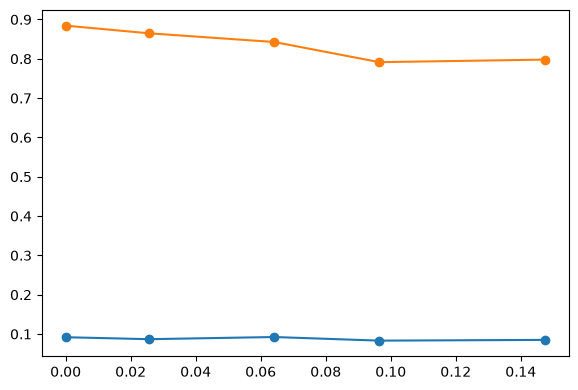

In [29]:
def train_transformer_condition(task,train_instances,val_instances,mode,seed,args=TRAIN_ARGS):
    model,loss=repo_train_one(task,train_instances,mode,seed,args,DEVICE)
    condition="outcome" if mode=="outcome" else "mixed_process"
    metrics=repo_rollout_evaluate(model,task,val_instances,condition,args,DEVICE)
    row={"seed":seed,"mode":mode,"loss":loss,**metrics}
    del model
    if DEVICE.type=="cuda": torch.cuda.empty_cache()
    return row


def run_reversibility_sweep():
    depth=8; etas=[0.0,0.10,0.25,0.50,1.0]
    train_specs=make_prompt_specs(CFG.train_size,depth,seed=501)
    train_prompts={s.prompt for s in train_specs}
    val_specs=make_prompt_specs(CFG.val_size,depth,seed=101,excluded=train_prompts)
    rows=[]
    for eta in etas:
        table,selected,eta_eff=executor_at_eta(eta)
        train=[instance_from_spec(s,table) for s in train_specs]
        val=[instance_from_spec(s,table) for s in val_specs]
        task=task_for_instances(f"boolean_circuit_8_eta{eta:.2f}",depth,train[0])
        margin=terminal_nonuniformity(table,val_specs[:min(500,len(val_specs))])
        counts=Counter(v.gold for v in val)
        majority=max(counts.values())/len(val)
        entropy=-sum((c/len(val))*math.log(c/len(val)+1e-30) for c in counts.values())
        print(f"eta={eta:.2f} effective={eta_eff:.3f} nonuniform={margin['mean_nonuniformity']:.3f} majority={majority:.3f}")
        for mode in ("outcome","process"):
            for seed in CFG.seeds:
                r=train_transformer_condition(task,train,val,mode,seed)
                rows.append({"eta_target":eta,"eta_effective":eta_eff,"n_nonrev_gate_types":len(selected),
                             "majority_baseline":majority,"answer_entropy":entropy,**margin,**r})
                pd.DataFrame(rows).to_csv(OUT/"p3_reversibility_transformer.csv",index=False)
    df=pd.DataFrame(rows)
    agg=df.groupby(["eta_target","eta_effective","mode"],as_index=False).agg(
        answer_accuracy=("answer_accuracy","mean"),answer_sd=("answer_accuracy","std"),
        exact_trace_accuracy=("exact_trace_accuracy","mean"),
        majority_baseline=("majority_baseline","mean"),mean_nonuniformity=("mean_nonuniformity","mean"),n=("seed","count"))
    agg.to_csv(OUT/"p3_reversibility_transformer_aggregate.csv",index=False)
    display(agg)
    fig,ax=plt.subplots(figsize=(6.8,4.5))
    for mode,g in agg.groupby("mode"):
        ax.plot(g.mean_nonuniformity,g.answer_accuracy,marker="o",label=mode)
    ax.plot(agg[agg.mode=="outcome"].mean_nonuniformity,agg[agg.mode=="outcome"].majority_baseline,marker="x",linestyle="--",label="majority baseline")
    ax.set_xlabel("mean terminal non-uniformity"); ax.set_ylabel("answer accuracy")
    ax.set_title("Breaking reversibility restores terminal signal")
    ax.legend(); fig.tight_layout(); plt.show()
    return df,agg

# This is the first expensive full-Transformer cell.
rev_df, rev_agg = run_reversibility_sweep()


**Run the previous cell first in pilot mode.** If outcome accuracy increases only in lock-step with the majority baseline, do not present it as executor learning. The useful result is excess accuracy / gate-dependent behavior tracking the computed non-uniformity while PROCESS remains stable.


# Pending 4A — supervision stride on the full Transformer

For `k < D`, only every `k`-th `gate>state` item is placed in the continuation. For `k=D`, the endpoint is treated as **exact OUTCOME** (`: answer`) so the endpoint of the sweep really is the original outcome objective rather than a duplicated final-state target.

This arm tests monotone learning latency and performance versus stride. It does **not** by itself estimate an `epsilon` exponent; the quantitative exponent test is the matrix arm below.


In [ ]:
def stride_target(inst,k,depth):
    if k>=depth: return f" : {inst.gold}\n"
    steps=inst.correct_trace.split()
    assert len(steps)==depth and depth%k==0
    sparse=" ".join(steps[k-1::k])
    return f" {sparse} : {inst.gold}\n"


class StrideDataset(Dataset):
    def __init__(self,instances,task,k,depth):
        tok=task.tokenizer; width=task.block_size-1
        self.x=torch.full((len(instances),width),tok.pad_id,dtype=torch.uint8)
        self.y=torch.full((len(instances),width),tok.pad_id,dtype=torch.uint8)
        self.mask=torch.zeros((len(instances),width),dtype=torch.bool)
        for row,inst in enumerate(instances):
            p=tok.encode(inst.prompt); full=p+tok.encode(stride_target(inst,k,depth))
            if len(full)>task.block_size: raise ValueError((k,len(full),task.block_size))
            seq=torch.tensor(full,dtype=torch.uint8); L=len(full)-1
            self.x[row,:L]=seq[:-1]; self.y[row,:L]=seq[1:]; self.mask[row,len(p)-1:L]=True
    def __len__(self): return len(self.x)
    def __getitem__(self,i): return self.x[i],self.y[i],self.mask[i]


def expected_stride_trace(inst,k,depth):
    if k>=depth: return None
    steps=inst.correct_trace.split(); return " ".join(steps[k-1::k])


def parse_tail(text):
    line=text.split("\n",1)[0]
    if ":" not in line: return None,None
    tr,ans=line.rsplit(":",1); m=re.search(r"[01]{4}",ans)
    return tr.strip(),(m.group(0) if m else None)


@torch.inference_mode()
def evaluate_stride(model,task,instances,k,depth,args):
    model.eval(); answer=trace=total=0
    buckets=defaultdict(list)
    for inst in instances:
        ids=task.tokenizer.encode(inst.prompt); buckets[len(ids)].append((ids,inst))
    max_new=8 if k>=depth else task.max_new_tokens
    for rows in buckets.values():
        for st in range(0,len(rows),args.eval_batch_size):
            batch=rows[st:st+args.eval_batch_size]
            ctx=torch.tensor([x[0] for x in batch],dtype=torch.long,device=DEVICE)
            plen=ctx.shape[1]; out=model.generate(ctx,max_new_tokens=max_new,stop_id=task.tokenizer.newline_id,greedy=True)
            for ids,(_,inst) in zip(out.tolist(),batch):
                tr,ans=parse_tail(task.tokenizer.decode(ids[plen:]))
                answer+=int(ans==inst.gold)
                if k<depth: trace+=int(tr==expected_stride_trace(inst,k,depth))
                total+=1
    return {"answer_accuracy":answer/total,"exact_stride_trace":None if k>=depth else trace/total}


def build_repo_model(task,seed,args):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    return GPTModel(vocab_size=task.tokenizer.vocab_size,block_size=task.block_size,pad_id=task.tokenizer.pad_id,
                    n_embd=args.embedding,n_head=args.heads,n_layer=args.layers,dropout=args.dropout).to(DEVICE)


def make_adamw(model,args):
    try: return torch.optim.AdamW(model.parameters(),lr=args.lr,weight_decay=args.weight_decay,fused=DEVICE.type=="cuda")
    except Exception: return torch.optim.AdamW(model.parameters(),lr=args.lr,weight_decay=args.weight_decay)


def train_stride_run(task,train,val,k,depth,seed,args=TRAIN_ARGS):
    ds=StrideDataset(train,task,k,depth)
    gen=torch.Generator().manual_seed(args.batch_seed)
    dl=DataLoader(ds,batch_size=args.batch_size,shuffle=True,drop_last=True,num_workers=args.workers,
                  pin_memory=DEVICE.type=="cuda",generator=gen)
    it=iter(dl); model=build_repo_model(task,seed,args); opt=make_adamw(model,args)
    use_bf16=DEVICE.type=="cuda" and torch.cuda.is_bf16_supported(); rows=[]
    for step in tqdm(range(1,max(CFG.checkpoints)+1),desc=f"stride k={k} seed={seed}"):
        try: x,y,m=next(it)
        except StopIteration: it=iter(dl); x,y,m=next(it)
        x=x.to(DEVICE,dtype=torch.long,non_blocking=True); y=y.to(DEVICE,dtype=torch.long,non_blocking=True); m=m.to(DEVICE,dtype=torch.float32,non_blocking=True)
        opt.zero_grad(set_to_none=True)
        if use_bf16:
            with torch.autocast(device_type="cuda",dtype=torch.bfloat16): _,loss=model(x,targets=y,mask=m)
        else: _,loss=model(x,targets=y,mask=m)
        loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),args.grad_clip); opt.step()
        if step in CFG.checkpoints:
            met=evaluate_stride(model,task,val,k,depth,args)
            rows.append({"k":k,"depth":depth,"seed":seed,"step":step,"loss":float(loss.detach()),**met})
            model.train()
    del model,opt,dl,ds
    if DEVICE.type=="cuda": torch.cuda.empty_cache()
    return rows


def run_stride_transformer():
    depth=16; ks=[1,2,4,8,16]
    task=TASKS["boolean_circuit_16"]
    # Exact same prompt/answer pool for every k.
    train_specs=make_prompt_specs(CFG.train_size,depth,501); train_prompts={s.prompt for s in train_specs}
    val_specs=make_prompt_specs(CFG.val_size,depth,101,train_prompts)
    train=[instance_from_spec(s,TRUE_REPO) for s in train_specs]; val=[instance_from_spec(s,TRUE_REPO) for s in val_specs]
    rows=[]
    for k in ks:
        for seed in CFG.seeds:
            rows.extend(train_stride_run(task,train,val,k,depth,seed))
            pd.DataFrame(rows).to_csv(OUT/"p4a_stride_transformer.csv",index=False)
    df=pd.DataFrame(rows)
    threshold=1/K+0.05
    summary=[]
    for (k,seed),g in df.groupby(["k","seed"]):
        hit=g[g.answer_accuracy>=threshold]
        summary.append({"k":k,"seed":seed,"leave_chance_step":None if hit.empty else int(hit.step.iloc[0]),
                        "final_answer":float(g.sort_values('step').answer_accuracy.iloc[-1]),
                        "final_stride_trace":g.sort_values('step').exact_stride_trace.iloc[-1]})
    sdf=pd.DataFrame(summary); sdf.to_csv(OUT/"p4a_stride_transformer_summary.csv",index=False)
    display(sdf)
    return df,sdf

stride_df,stride_summary = run_stride_transformer()


# Pending 4B — supervision-stride **exponent** in the transition-matrix model

This is the correct place to test the quantitative prediction

\[
T_k(\epsilon)\propto \epsilon^{-(k-2)}.
\]

The objective teacher-forces the state at block boundaries and supervises only the endpoint of each `k`-operation block. Thus each block routes terminal credit through `k-1` compositions. `k=1` is ordinary process supervision; `k=D` is ordinary outcome supervision.


In [ ]:
def project_rows_simplex(V):
    shape=V.shape; X=V.reshape(-1,K)
    u,_=torch.sort(X,dim=1,descending=True)
    cssv=torch.cumsum(u,dim=1)-1
    ind=torch.arange(1,K+1,device=V.device,dtype=V.dtype)[None,:]
    cond=u-cssv/ind>0
    rho=cond.sum(dim=1)-1
    theta=cssv.gather(1,rho[:,None]).squeeze(1)/(rho.to(V.dtype)+1)
    W=torch.clamp(X-theta[:,None],min=0)
    return W.reshape(shape)


def make_balanced_specs_matrix(depth,n_sequences,seed):
    # Cross random gate sequences with all 16 starts; exact start/terminal uniformity for reversible T.
    gates=sample_gate_ids(n_sequences,depth,seed)
    gates=np.repeat(gates,K,axis=0); s0=np.tile(np.arange(K),n_sequences)
    return s0,gates


def true_states(table,s0,gates):
    states=[np.asarray(s0,dtype=np.int64)]
    s=states[0]
    for t in range(gates.shape[1]):
        s=table[gates[:,t],s]; states.append(s.copy())
    return states


def stride_loss(P,s0,gates,states,k):
    gates=torch.as_tensor(gates,device=P.device,dtype=torch.long)
    states_t=[torch.as_tensor(s,device=P.device,dtype=torch.long) for s in states]
    eye=torch.eye(K,dtype=P.dtype,device=P.device)
    D=gates.shape[1]; losses=[]
    for a in range(0,D,k):
        b=min(a+k,D); q=eye[states_t[a]]
        for t in range(a,b): q=torch.bmm(q[:,None,:],P[gates[:,t]]).squeeze(1)
        prob=q.gather(1,states_t[b][:,None]).squeeze(1).clamp_min(1e-15)
        losses.append(-torch.log(prob))
    return torch.stack(losses,dim=1).mean()


def gate_recovery(P,true_table=TRUE_REPO):
    pred=P.argmax(dim=-1).detach().cpu().numpy(); return float((pred==true_table).mean())


def run_matrix_stride_trial(k,eps,seed,depth=16,lr=0.5,max_steps=30_000,optimizer_name="gd"):
    s0,gates=make_balanced_specs_matrix(depth,CFG.matrix_sequences,seed=11100+seed+depth)
    states=true_states(TRUE_REPO,s0,gates)
    P=make_learned_P(eps,seed=11200+seed+depth).detach().clone().requires_grad_(True)
    phi0,_=phi_gamma(P); opt=None
    if optimizer_name=="adamw": opt=torch.optim.AdamW([P],lr=lr,weight_decay=0.0)
    pending=None; check_every=10 if PROFILE=="pilot" else 20
    for step in range(1,max_steps+1):
        loss=stride_loss(P,s0,gates,states,k)
        if opt is None:
            if P.grad is not None: P.grad.zero_()
            loss.backward()
            with torch.no_grad():
                G=P.grad-P.grad.mean(dim=-1,keepdim=True)
                P.copy_(project_rows_simplex(P-lr*G))
        else:
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            with torch.no_grad(): P.copy_(project_rows_simplex(P))
        if step<=100 or step%check_every==0:
            ph,ga=phi_gamma(P); above=ph>=2*phi0
            if above and pending is not None: return {"k":k,"eps":eps,"seed":seed,"optimizer":optimizer_name,"escape":pending,"censored":False,"phi0":phi0,"phi":ph,"gamma":ga}
            pending=step if above else None
    ph,ga=phi_gamma(P)
    return {"k":k,"eps":eps,"seed":seed,"optimizer":optimizer_name,"escape":max_steps,"censored":True,"phi0":phi0,"phi":ph,"gamma":ga}


def run_stride_matrix_exponents():
    # k=16 is intentionally allowed to censor; its predicted exponent 14 is extremely steep.
    grids={1:[.10,.07,.05],2:[.15,.10,.07,.05],4:[.30,.24,.19,.15],8:[.45,.40,.35,.30],16:[.48,.45,.42,.39]}
    caps={1:500,2:2_000,4:20_000,8:40_000,16:100_000}
    seeds=CFG.seeds if PROFILE=="paper" else (2001,)
    rows=[]
    for k,epss in grids.items():
        for eps in epss:
            for seed in seeds:
                r=run_matrix_stride_trial(k,eps,seed,max_steps=caps[k],optimizer_name="gd")
                rows.append(r); print(r)
                pd.DataFrame(rows).to_csv(OUT/"p4b_stride_matrix.csv",index=False)
    df=pd.DataFrame(rows); fits=[]
    for k,g in df[~df.censored].groupby("k"):
        if len(g)>=3:
            med=g.groupby("eps",as_index=False).escape.median()
            slope=np.polyfit(np.log(1/med.eps),np.log(med.escape),1)[0]
            fits.append({"k":k,"measured_exponent":slope,"predicted_k_minus_2":max(k-2,0),"n_scales":len(med)})
    fitdf=pd.DataFrame(fits); fitdf.to_csv(OUT/"p4b_stride_matrix_fits.csv",index=False)
    display(fitdf)
    return df,fitdf

matrix_stride_df,matrix_stride_fits = run_stride_matrix_exponents()


# Pending 5 — degree-graded finite differences

### 5A. Exact matrix positive control

Along `P_g(alpha) = U + alpha (T_g-U)`, mixed `U/Delta` terms annihilate each other. Therefore the terminal loss changes first at order `alpha^D`, while the teacher-forced local process loss changes at order `alpha`.

This cell measures those orders at `D in {3,4,5}` with no fitting choices beyond a geometric alpha grid.


In [11]:
def matrix_losses_on_executor_path(alpha,depth,nseq=256,seed=123):
    T=torch.tensor(np.eye(K)[TRUE_REPO],dtype=torch.float64,device=DEVICE)  # [M,K,K], row i -> T[g,i]
    P=torch.full_like(T,1/K)+alpha*(T-torch.full_like(T,1/K))
    gates=sample_gate_ids(nseq,depth,seed)
    s0=np.random.default_rng(seed+1).integers(0,K,size=nseq)
    states=true_states(TRUE_REPO,s0,gates); y=states[-1]
    gates_t=torch.tensor(gates,device=DEVICE); s0_t=torch.tensor(s0,device=DEVICE); y_t=torch.tensor(y,device=DEVICE)
    eye=torch.eye(K,dtype=P.dtype,device=DEVICE); q=eye[s0_t]
    for t in range(depth): q=torch.bmm(q[:,None,:],P[gates_t[:,t]]).squeeze(1)
    Lout=-torch.log(q.gather(1,y_t[:,None]).squeeze(1)).mean()
    terms=[]
    for t in range(depth):
        a=torch.tensor(states[t],device=DEVICE); b=torch.tensor(states[t+1],device=DEVICE); gt=gates_t[:,t]
        terms.append(-torch.log(P[gt,a,b]))
    Lproc=torch.stack(terms,1).mean()
    return float(Lout),float(Lproc)


def local_loglog_order(alphas,deltas):
    alphas=np.asarray(alphas); deltas=np.asarray(deltas)
    ok=np.isfinite(deltas)&(deltas>1e-14)
    x=np.log(alphas[ok]); y=np.log(deltas[ok])
    if len(x)<3: return math.nan
    # use the smallest numerically-resolved half of the grid
    n=max(3,len(x)//2); return float(np.polyfit(x[:n],y[:n],1)[0])


def run_matrix_degree_control():
    alphas=np.geomspace(1e-3,2e-1,14)
    rows=[]; summary=[]
    for D in [3,4,5]:
        L0o,L0p=matrix_losses_on_executor_path(0.0,D,seed=14000+D)
        do=[]; dp=[]
        for a in alphas:
            Lo,Lp=matrix_losses_on_executor_path(float(a),D,seed=14000+D)
            do.append(abs(Lo-L0o)); dp.append(abs(Lp-L0p)); rows.append({"D":D,"alpha":a,"delta_out":do[-1],"delta_proc":dp[-1]})
        summary.append({"D":D,"outcome_order":local_loglog_order(alphas,do),"process_order":local_loglog_order(alphas,dp),"pred_outcome":D,"pred_process":1})
    df=pd.DataFrame(rows); sdf=pd.DataFrame(summary)
    df.to_csv(OUT/"p5a_matrix_degree_grid.csv",index=False); sdf.to_csv(OUT/"p5a_matrix_degree_orders.csv",index=False)
    display(sdf)
    return df,sdf

matrix_degree_df,matrix_degree_summary=run_matrix_degree_control()


,D,outcome_order,process_order,pred_outcome,pred_process
0,3,2.999996,0.971239,3,1
1,4,3.999992,0.971239,4,1
2,5,4.990112,0.971239,5,1


### 5B. Reusable Transformer finite-difference harness

The draft says to measure `L(theta_pi + alpha d)` along **the executor direction `d`**, but the current repository/draft does not define a unique parameter-space `d` for depths 3, 4, 5. A random direction would not test the claim. The harness below is therefore intentionally explicit: it runs only after you provide a `direction` dictionary keyed by parameter name (for example, a hand-coded executor direction or a frozen oracle-minus-collapse direction).

Do **not** put a number from this section in the paper unless the construction of `d` is stated and fixed before looking at the slopes.


In [12]:
def finite_difference_along_direction(model,loss_fn,direction,alphas):
    base={n:p.detach().clone() for n,p in model.named_parameters()}
    with torch.no_grad(): L0=float(loss_fn(model))
    rows=[]
    for a in alphas:
        with torch.no_grad():
            for n,p in model.named_parameters(): p.copy_(base[n]+float(a)*direction[n].to(p))
        L=float(loss_fn(model)); rows.append({"alpha":float(a),"loss":L,"delta":abs(L-L0)})
    with torch.no_grad():
        for n,p in model.named_parameters(): p.copy_(base[n])
    order=local_loglog_order([r['alpha'] for r in rows],[r['delta'] for r in rows])
    return pd.DataFrame(rows),order

print("Transformer F.3 harness ready. Supply an explicitly justified executor direction d before running it.")


Transformer F.3 harness ready. Supply an explicitly justified executor direction d before running it.


# Pending 6 — audit the released trace-cleaning protocol

The draft currently needs one factual check: is `f` a fraction of the **total pool**, or a fraction of the **corrupted subset**? We inspect the actual imported function instead of guessing.


In [13]:
def audit_cleaning_protocol(rho0=0.8, f_values=(0.55,0.65)):
    src=inspect.getsource(build_filtered_subset)
    print(src)
    semantics="corrupted_subset" if "f * n_corrupt" in src or "f*n_corrupt" in src else "unknown"
    rows=[]
    for f in f_values:
        if semantics=="corrupted_subset":
            total_removed=f*(1-rho0)
            rows.append({"reported_f":f,"meaning":"fraction of corrupted subset","implied_fraction_total_pool":total_removed})
        else:
            rows.append({"reported_f":f,"meaning":"CHECK MANUALLY","implied_fraction_total_pool":math.nan})
    df=pd.DataFrame(rows)
    df.to_csv(OUT/"p6_cleaning_protocol_audit.csv",index=False)
    display(df)
    if semantics=="corrupted_subset":
        print("IMPORTANT: current released code defines n_remove = round(f * n_corrupt).")
        print("At rho0=.8, f=.55/.65 means 11%/13% of the TOTAL pool, not 55%/65%.")
        print("Correct the paper wording or rerun a total-pool-removal protocol; do not silently relabel old results.")
    return df

cleaning_audit=audit_cleaning_protocol()


def build_filtered_subset(train_instances, ratio_scores, rho0, mode, f, corrupt_order, random_order):
    clean_flags = ratio_scores < rho0
    n_corrupt = int((~clean_flags).sum())
    n_remove = int(round(f * n_corrupt))

    if mode == "targeted":
        removed = corrupt_order[:n_remove]
    elif mode == "random":
        removed = random_order[:n_remove]
    else:
        raise ValueError(mode)

    keep_mask = np.ones(len(train_instances), dtype=bool)
    keep_mask[removed] = False
    keep = np.flatnonzero(keep_mask)

    subset_instances = [train_instances[i] for i in keep]
    subset_scores = ratio_scores[keep]
    realized_rho = float(np.mean(subset_scores < rho0))
    return subset_instances, subset_scores, realized_rho, n_remove



,reported_f,meaning,implied_fraction_total_pool
0,0.55,fraction of corrupted subset,0.11
1,0.65,fraction of corrupted subset,0.13


IMPORTANT: current released code defines n_remove = round(f * n_corrupt).
At rho0=.8, f=.55/.65 means 11%/13% of the TOTAL pool, not 55%/65%.
Correct the paper wording or rerun a total-pool-removal protocol; do not silently relabel old results.


# Extra — AdamW robustness of the escape law

This is not one of the bracketed pending markers, but it addresses the main reviewer objection: the theorem/escape validation uses gradient flow / projected GD while the full Transformer uses AdamW.

To isolate **optimizer** rather than parameterization, both arms below optimize `P` directly and project rows back to the simplex. `weight_decay=0`, matching the repository's main Transformer configuration.


In [14]:
def full_outcome_loss(P,s0,gates,gold):
    gates=torch.as_tensor(gates,device=P.device,dtype=torch.long); s0=torch.as_tensor(s0,device=P.device,dtype=torch.long); gold=torch.as_tensor(gold,device=P.device,dtype=torch.long)
    q=torch.eye(K,dtype=P.dtype,device=P.device)[s0]
    for t in range(gates.shape[1]): q=torch.bmm(q[:,None,:],P[gates[:,t]]).squeeze(1)
    return -torch.log(q.gather(1,gold[:,None]).squeeze(1).clamp_min(1e-15)).mean()


def run_escape_optimizer_trial(D,eps,seed,optimizer_name,lr,max_steps):
    s0,gates=make_balanced_specs_matrix(D,CFG.matrix_sequences,15000+D+seed)
    gold=apply_sequence(TRUE_REPO,s0,gates)
    P=make_learned_P(eps,16000+D+seed).detach().clone().requires_grad_(True)
    phi0,_=phi_gamma(P); opt=None
    if optimizer_name=="adamw": opt=torch.optim.AdamW([P],lr=lr,weight_decay=0.0)
    pending=None
    for step in range(1,max_steps+1):
        loss=full_outcome_loss(P,s0,gates,gold)
        if opt is None:
            if P.grad is not None:P.grad.zero_()
            loss.backward()
            with torch.no_grad():
                G=P.grad-P.grad.mean(dim=-1,keepdim=True); P.copy_(project_rows_simplex(P-lr*G))
        else:
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            with torch.no_grad(): P.copy_(project_rows_simplex(P))
        if step<=100 or step%20==0:
            ph,ga=phi_gamma(P); above=ph>=2*phi0
            if above and pending is not None: return {"D":D,"eps":eps,"seed":seed,"optimizer":optimizer_name,"escape":pending,"censored":False,"gamma":ga}
            pending=step if above else None
    ph,ga=phi_gamma(P); return {"D":D,"eps":eps,"seed":seed,"optimizer":optimizer_name,"escape":max_steps,"censored":True,"gamma":ga}


def run_optimizer_robustness():
    grids={3:[.15,.10,.07,.05],4:[.20,.14,.10,.07],6:[.30,.24,.19,.15]}
    caps={3:20_000,4:50_000,6:100_000}; rows=[]
    # These LRs need a pilot sanity check. Keep optimizer-specific LR fixed across eps/depth.
    lrs={"gd":0.5,"adamw":1e-2}
    seeds=CFG.seeds if PROFILE=="paper" else (2001,)
    for optname in ["gd","adamw"]:
        for D,epss in grids.items():
            for eps in epss:
                for seed in seeds:
                    r=run_escape_optimizer_trial(D,eps,seed,optname,lrs[optname],caps[D]); rows.append(r); print(r)
                    pd.DataFrame(rows).to_csv(OUT/"extra_optimizer_escape.csv",index=False)
    df=pd.DataFrame(rows); fits=[]
    for (optname,D),g in df[~df.censored].groupby(["optimizer","D"]):
        med=g.groupby("eps",as_index=False).escape.median()
        if len(med)>=3:
            slope=np.polyfit(np.log(1/med.eps),np.log(med.escape),1)[0]
            fits.append({"optimizer":optname,"D":D,"exponent":slope,"reference_D_minus_2":D-2})
    fitdf=pd.DataFrame(fits); fitdf.to_csv(OUT/"extra_optimizer_escape_fits.csv",index=False)
    display(fitdf); return df,fitdf

# optimizer_escape_df,optimizer_escape_fits = run_optimizer_robustness()


# Final aggregation / sanity checks

Run this after the experiment cells you want. It inventories outputs and highlights the claims that are safe to make only if the corresponding measurements exist.


In [15]:
def inventory_results():
    files=sorted(OUT.glob("*.csv"))
    print("CSV outputs:")
    for p in files: print(" -",p.name)
    required={
        "amplification":"p1_amplification_ratio.csv",
        "coupling":"p2_coupling_radius.csv",
        "reversibility":"p3_reversibility_transformer.csv",
        "stride_transformer":"p4a_stride_transformer.csv",
        "stride_exponent":"p4b_stride_matrix_fits.csv",
        "degree_control":"p5a_matrix_degree_orders.csv",
        "cleaning_audit":"p6_cleaning_protocol_audit.csv",
        "optimizer_robustness":"extra_optimizer_escape_fits.csv",
    }
    status={k:(OUT/v).exists() for k,v in required.items()}
    display(pd.DataFrame([{"item":k,"complete":v} for k,v in status.items()]))
    return status

inventory_results()


CSV outputs:
 - p1_amplification_ratio.csv
 - p1_amplification_ratio_fits.csv
 - p2_coupling_fits.csv
 - p2_coupling_radius.csv
 - p5a_matrix_degree_grid.csv
 - p5a_matrix_degree_orders.csv
 - p6_cleaning_protocol_audit.csv


,item,complete
0,amplification,True
1,coupling,True
2,reversibility,False
3,stride_transformer,False
4,stride_exponent,False
5,degree_control,True
6,cleaning_audit,True
7,optimizer_robustness,False


{'amplification': True,
 'coupling': True,
 'reversibility': False,
 'stride_transformer': False,
 'stride_exponent': False,
 'degree_control': True,
 'cleaning_audit': True,
 'optimizer_robustness': False}

## Recommended run order

1. Run setup + matrix helpers.
2. Run **P1**, **P2**, **P5A**, and **P6**. These are cheap and should finish first.
3. Run the **AdamW robustness pilot**. Inspect whether AdamW escapes instantly for every `eps`; if so reduce its LR before the paper run. Do not tune LR separately by `eps` or depth.
4. Run the **reversibility pilot** (`PROFILE="pilot"`). Check outcome accuracy *above the majority baseline* and against measured non-uniformity.
5. Run the **stride Transformer pilot**. Confirm `k=1` reproduces the standard PROCESS behavior and `k=16` reproduces OUTCOME.
6. Run the **matrix stride exponent pilot**. Expect large censoring for `k=16`; that is not a reason to cherry-pick the grid.
7. Only then switch to `PROFILE="paper"` and rerun from a fresh kernel.

For the manuscript, do not state the Transformer degree-graded `D vs 1` result until an explicit, pre-specified parameter-space executor direction `d` is added to section 5B and the result is measured. The matrix positive control is already exact and runnable.
